In [ ]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")


##  Kaggle Dataset Import & Setup


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'crop-recommendation-dataset' dataset.
Path to dataset files: /kaggle/input/crop-recommendation-dataset


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abhinand05/crop-production-in-india")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'crop-production-in-india' dataset.
Path to dataset files: /kaggle/input/crop-production-in-india


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anishaman07/agmarknet-india-commodity-prices-oct24-aug25")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'agmarknet-india-commodity-prices-oct24-aug25' dataset.
Path to dataset files: /kaggle/input/agmarknet-india-commodity-prices-oct24-aug25


In [ ]:
import os

print("Soil & Climate files:")
print(os.listdir("/kaggle/input/crop-recommendation-dataset"))

print("\nCrop Production files:")
print(os.listdir("/root/.cache/kagglehub/datasets/abhinand05/crop-production-in-india/versions/1"))

print("\nAgmarknet Price files:")
print(os.listdir("/kaggle/input/agmarknet-india-commodity-prices-oct24-aug25"))


Soil & Climate files:
['Crop_recommendation.csv', '.nfs000000005391170f0000015d']

Crop Production files:
['crop_production.csv']

Agmarknet Price files:
['.nfs00000000537359bb00000162', 'agmarknet-india-commodity-prices-2024-2025']


In [ ]:
import os

base_path = "/kaggle/input/agmarknet-india-commodity-prices-oct24-aug25"

print(os.listdir(base_path))

subfolder = base_path + "/agmarknet-india-commodity-prices-2024-2025"
print(os.listdir(subfolder))


['.nfs00000000537359bb00000162', 'agmarknet-india-commodity-prices-2024-2025']
['README.md', 'LICENSE.txt', 'agmarknet_india_historical_prices_2024_2025.csv']


# 1. Soil & Climate Dataset Processing (Agro-Zoning Input)



In [ ]:
soil_df = pd.read_csv("/kaggle/input/crop-recommendation-dataset/Crop_recommendation.csv")

soil_df.head()


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
soil_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [ ]:
# Remove label
# Since this project focuses on UNSUPERVISED agro-zoning,
# the label must be removed to avoid supervised learning bias.

soil_X = soil_df.drop(columns=["label"])
soil_X.head()

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


In [ ]:
soil_X.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
soil_X.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0


# 2. Crop Production Dataset Processing (Historical Yield Analysis)


In [ ]:
crop_prod_df = pd.read_csv("/root/.cache/kagglehub/datasets/abhinand05/crop-production-in-india/versions/1/crop_production.csv")

crop_prod_df.head()


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [ ]:
crop_prod_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB


In [ ]:
# -------------------------------
# Step 2.1: Check missing values
# -------------------------------
# Production is required to compute yield.
# Rows with missing production cannot contribute to historical performance.

crop_prod_df.isnull().sum()


,0
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0
Production,3730


In [ ]:
# Yield computation requires production data.
# Rows with missing production are removed to ensure valid yield estimation.

crop_prod_df = crop_prod_df.dropna(subset=["Production"])

crop_prod_df.isnull().sum()


,0
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0
Production,0


In [ ]:
# -------------------------------
# Step 2.2: Compute crop yield
# -------------------------------
# Yield is calculated as Production per unit Area.
# This metric represents historical crop performance independent of land size.

crop_prod_df["Yield"] = crop_prod_df["Production"] / crop_prod_df["Area"]
crop_prod_df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0,1.594896
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0,0.500000
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0,3.147059
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0,3.642045
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0,0.229167


In [ ]:
# check Yield values
crop_prod_df["Yield"].describe()


,Yield
count,242361.000000
mean,41.649059
std,817.572839
min,0.000000
25%,0.513514
50%,1.000000
75%,2.355450
max,88000.000000


In [ ]:
# -------------------------------
# Step 2.3: Cap extreme Yield values using IQR
# -------------------------------
# This limits the influence of extreme outliers while
# preserving the overall yield distribution.

Q1 = crop_prod_df["Yield"].quantile(0.25)
Q3 = crop_prod_df["Yield"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

# Cap yield values above the upper bound
crop_prod_df["Yield"] = crop_prod_df["Yield"].clip(upper=upper_bound)


In [ ]:
crop_prod_df["Yield"].describe()


,Yield
count,242361.000000
mean,1.743024
std,1.688774
min,0.000000
25%,0.513514
50%,1.000000
75%,2.355450
max,5.118355


In [ ]:
crop_prod_df['Season'].value_counts()

,count
Season,
Kharif,94283
Rabi,66160
Whole Year,56127
Summer,14811
Winter,6050
Autumn,4930


In [ ]:
# -------------------------------
# Step 2.4 : Clean season names and keep required seasons
# -------------------------------
crop_prod_df["Season"] = crop_prod_df["Season"].str.strip()

allowed_seasons = ["Kharif", "Rabi", "Summer"]
crop_prod_df = crop_prod_df[crop_prod_df["Season"].isin(allowed_seasons)]

crop_prod_df["Season"].value_counts()


,count
Season,
Kharif,94283
Rabi,66160
Summer,14811


In [ ]:
# -------------------------------
# Step 2.5 : Aggregate historical yield
# -------------------------------
# We group data by State, Season, and Crop
# and calculate average yield.
# This gives stable historical performance for each crop.

yield_agg_df = (
    crop_prod_df
    .groupby(["State_Name", "Season", "Crop"], as_index=False)
    .agg({"Yield": "mean"})
)

yield_agg_df.shape

(1243, 4)

In [ ]:
yield_agg_df.head()

,State_Name,Season,Crop,Yield
0,Andaman and Nicobar Islands,Kharif,Arecanut,1.651464
1,Andaman and Nicobar Islands,Kharif,Other Kharif pulses,0.536684
2,Andaman and Nicobar Islands,Kharif,Rice,2.895401
3,Andaman and Nicobar Islands,Rabi,Arecanut,1.488736
4,Andaman and Nicobar Islands,Rabi,Arhar/Tur,0.476111


# 3. Market Price Dataset Processing (Economic Value Indicator)


In [ ]:
price_df = pd.read_csv("/kaggle/input/agmarknet-india-commodity-prices-oct24-aug25/"
    "agmarknet-india-commodity-prices-2024-2025/""agmarknet_india_historical_prices_2024_2025.csv")

price_df.head()


,Sl no.,District Name,Market Name,Commodity,Variety,Grade,Min Price (Rs./Quintal),Max Price (Rs./Quintal),Modal Price (Rs./Quintal),Price Date,State
0,1,Auraiya,Achalda,Wheat,Dara,FAQ,2350.0,2550.0,2450.0,05 Apr 2025,Uttar Pradesh
1,2,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2500.0,2470.0,14 Jun 2025,Uttar Pradesh
2,3,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2500.0,2470.0,23 Jun 2025,Uttar Pradesh
3,4,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2520.0,2470.0,26 Jun 2025,Uttar Pradesh
4,5,Auraiya,Achalda,Wheat,Dara,FAQ,2400.0,2550.0,2500.0,03 Jun 2025,Uttar Pradesh


In [ ]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1118899 entries, 0 to 1118898
Data columns (total 11 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Sl no.                     1118899 non-null  int64  
 1   District Name              1118899 non-null  object 
 2   Market Name                1118899 non-null  object 
 3   Commodity                  1118899 non-null  object 
 4   Variety                    1118899 non-null  object 
 5   Grade                      1118899 non-null  object 
 6   Min Price (Rs./Quintal)    1118899 non-null  float64
 7   Max Price (Rs./Quintal)    1118899 non-null  float64
 8   Modal Price (Rs./Quintal)  1118899 non-null  float64
 9   Price Date                 1118899 non-null  object 
 10  State                      1118899 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 93.9+ MB


In [ ]:
# -------------------------------
# Step 3.1: Select required columns from price data
# -------------------------------
# Only crop name and modal price are needed
# for economic comparison in recommendations.

price_df = price_df[["Commodity", "Modal Price (Rs./Quintal)"]]
price_df.head()

,Commodity,Modal Price (Rs./Quintal)
0,Wheat,2450.0
1,Wheat,2470.0
2,Wheat,2470.0
3,Wheat,2470.0
4,Wheat,2500.0


In [ ]:
#  Rename columns for clarity

price_df = price_df.rename(columns={
    "Commodity": "Crop",
    "Modal Price (Rs./Quintal)": "Modal_Price"
})
price_df.head()


,Crop,Modal_Price
0,Wheat,2450.0
1,Wheat,2470.0
2,Wheat,2470.0
3,Wheat,2470.0
4,Wheat,2500.0


In [ ]:
# Check missing values in price data
price_df.isnull().sum()


,0
Crop,0
Modal_Price,0


In [ ]:
# -------------------------------
# Step 3.2: Aggregate market price by crop
# -------------------------------
# Multiple price records exist for each crop.
# We take the average modal price to represent
# the overall selling value of that crop.

price_agg_df = (
    price_df
    .groupby("Crop", as_index=False)
    .agg({"Modal_Price": "mean"})
)
price_agg_df.head()

,Crop,Modal_Price
0,Apple,9004.111406
1,Arhar (Tur/Red Gram)(Whole),7286.404794
2,Bajra(Pearl Millet/Cumbu),2403.442858
3,Banana,2573.836778
4,Bhindi(Ladies Finger),3014.642133


In [ ]:
price_agg_df.shape

(23, 2)

In [ ]:
# Rename aggregated price column

price_agg_df = price_agg_df.rename(columns={"Modal_Price": "Avg_Modal_Price"})
price_agg_df.head()

,Crop,Avg_Modal_Price
0,Apple,9004.111406
1,Arhar (Tur/Red Gram)(Whole),7286.404794
2,Bajra(Pearl Millet/Cumbu),2403.442858
3,Banana,2573.836778
4,Bhindi(Ladies Finger),3014.642133


# 4. Agro-Zone Discovery (Unsupervised Clustering)

In [ ]:
# -------------------------------
# Step 4.1: Standardize soil & climate features
# -------------------------------
# K-Means is distance-based.
# Scaling ensures all features contribute fairly.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

soil_scaled = scaler.fit_transform(soil_X)



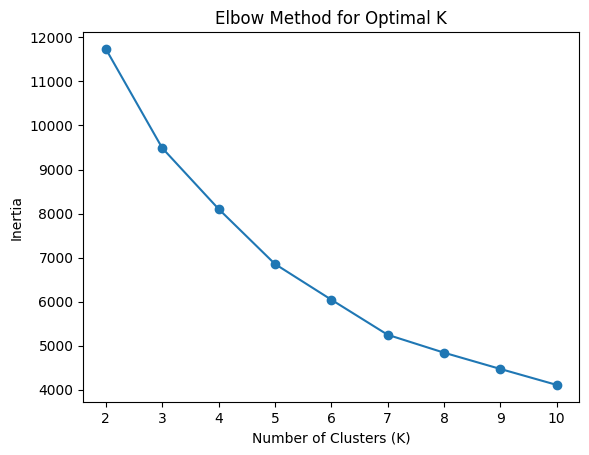

In [ ]:
# -------------------------------
# Step 4.2: Elbow Method to find optimal K
# -------------------------------
# We calculate inertia (within-cluster distance)
# for different values of K and observe the elbow point.

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 11)  # testing K from 2 to 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(soil_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()


In [ ]:
# -------------------------------
# Step 4.3: Silhouette score validation for K = 5
# -------------------------------
# After observing the elbow graph, K = 5 looks like a good choice.
# To confirm this, we use the silhouette score.
#
# The silhouette score tells us how well the data points fit within
# their assigned clusters compared to other clusters.
# A higher value means better separation between clusters.

from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=10)

cluster_labels = kmeans_5.fit_predict(soil_scaled)

sil_score = silhouette_score(soil_scaled, cluster_labels)

sil_score


np.float64(0.2924747941597334)

In [ ]:
# -------------------------------
# Step 4.4: Fit final K-Means model and assign Zone IDs
# -------------------------------
# Using K = 5 as decided from elbow and silhouette analysis.
# Each soil sample is assigned to one agro-zone.

from sklearn.cluster import KMeans

final_kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

soil_X["Zone_ID"] = final_kmeans.fit_predict(soil_scaled)


In [ ]:
soil_X["Zone_ID"].value_counts()



,count
Zone_ID,
0,627
2,580
1,558
4,235
3,200


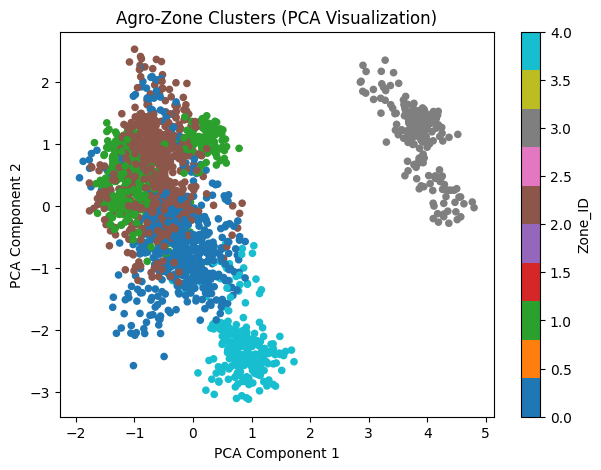

In [ ]:
# -------------------------------
# Step 4.6: Visualize agro-zones using PCA (for visualization only)
# -------------------------------
# PCA is used only to reduce dimensions for plotting.
# Clustering is already done on full feature space.

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
soil_pca = pca.fit_transform(soil_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(
    soil_pca[:, 0],
    soil_pca[:, 1],
    c=soil_X["Zone_ID"],
    cmap="tab10",
    s=20
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Agro-Zone Clusters (PCA Visualization)")
plt.colorbar(label="Zone_ID")
plt.show()


In [ ]:
# -------------------------------
# Step 4.7: Agro-zone profiling
# -------------------------------
# This step helps us understand the characteristics of each agro-zone by looking at average soil and climate values within each zone.

zone_profile_df = (
    soil_X
    .groupby("Zone_ID")
    .mean()
    .reset_index()
)

zone_profile_df


,Zone_ID,N,P,K,temperature,humidity,ph,rainfall
0,0,25.743222,52.052632,23.151515,29.572003,65.557379,6.631671,74.132023
1,1,99.439068,41.508961,37.512545,25.635258,78.655925,6.437123,75.781013
2,2,49.041379,32.860345,34.091379,24.539337,85.108381,6.516712,168.067362
3,3,21.990000,133.375000,200.000000,23.240259,87.104305,5.977800,91.133304
4,4,28.697872,67.510638,45.561702,19.696806,23.326425,6.415449,98.500969


# Agro-Zone Interpretation (Based on Soil & Climate Profiling)

After clustering the soil and climate data into five agro-zones, we analyzed the average soil nutrients and climatic conditions within each zone.
This profiling helps us understand what type of agricultural land each zone represents and makes the clustering results interpretable.
<br><br>


# 🌱 Zone 0: Low Fertility, Moderate Climate Zone

Low Nitrogen (N) and Potassium (K) levels

Moderate temperature

Lower rainfall compared to other zones

**Interpretation:**
This zone represents relatively dry land with moderate soil fertility. Crops suited to low-input or drought-tolerant conditions may perform better here.

<br>


# 🌾 Zone 1: Nitrogen-Rich, Warm Zone

Very high Nitrogen (N) content

Moderate rainfall

Warm temperature conditions

**Interpretation:**
This zone represents fertile agricultural land with good nitrogen availability, suitable for crops that require higher nutrient levels and warmer climates.

<br>


# 🌧️ Zone 2: High Rainfall, High Humidity Zone

Moderate nutrient levels

Very high rainfall

High humidity

**Interpretation:**
This zone represents wet, rain-fed agricultural regions. Crops that thrive in high moisture and humid conditions are more suitable for this zone.

<br>


# 🧪 Zone 3: Mineral-Rich Soil Zone

Extremely high Potassium (K)

High Phosphorus (P)

Moderate rainfall and temperature

**Interpretation:**
This zone represents mineral-rich soils, which are beneficial for crops that require strong root development and higher nutrient absorption.

<br>



# ❄️ Zone 4: Cool and Dry Zone

Lower temperature

Low humidity

Moderate nutrient levels

**Interpretation:**
This zone represents cooler and relatively dry climatic conditions. Crops adapted to cooler environments and lower moisture levels are more appropriate here.

<br>


# ✅ Summary

These agro-zones provide a meaningful grouping of land based on soil fertility and climate similarity.
In the next phase, these zones will be used to recommend suitable crops for different seasons using historical yield data and market prices.

# 5. Crop Recommendation Logic (Zone-wise & Season-wise)


In [ ]:
# -------------------------------
# Step 5.1: Prepare yield data for recommendations
# -------------------------------
# Since agro-zones are not tied to specific locations,
# we aggregate yield at Season + Crop level.
# This represents general historical performance.

season_crop_yield_df = (
    yield_agg_df
    .groupby(["Season", "Crop"], as_index=False)
    .agg({"Yield": "mean"})
)

season_crop_yield_df.head()


,Season,Crop,Yield
0,Kharif,Arecanut,1.452748
1,Kharif,Arhar/Tur,0.791623
2,Kharif,Bajra,0.996793
3,Kharif,Banana,4.905159
4,Kharif,Barley,1.097925


In [ ]:
# -------------------------------
# Step 5.2: Merge yield and market price data
# -------------------------------
# This combines historical crop performance (Yield)
# with economic value (Avg_Modal_Price).

yield_price_df = (
    season_crop_yield_df
    .merge(price_agg_df, on="Crop", how="inner")
)

yield_price_df.head()


,Season,Crop,Yield,Avg_Modal_Price
0,Kharif,Banana,4.905159,2573.836778
1,Kharif,Brinjal,5.114165,2317.671478
2,Kharif,Cabbage,4.874834,1884.678058
3,Kharif,Garlic,2.400661,12773.246005
4,Kharif,Groundnut,1.076250,5089.756789


In [ ]:
# -------------------------------
# Step 5.3: Normalize Yield and Market Price
# -------------------------------
# Yield is normalized within each season.
# Price is normalized globally across all crops.

from sklearn.preprocessing import MinMaxScaler

# Normalize Yield (season-wise)
yield_price_df["Norm_Yield"] = (
    yield_price_df
    .groupby("Season")["Yield"]
    .transform(lambda x: MinMaxScaler().fit_transform(x.values.reshape(-1, 1)).flatten())
)

# Normalize Price (global)
price_scaler = MinMaxScaler()
yield_price_df["Norm_Price"] = price_scaler.fit_transform(
    yield_price_df[["Avg_Modal_Price"]]
)

yield_price_df.head()


,Season,Crop,Yield,Avg_Modal_Price,Norm_Yield,Norm_Price
0,Kharif,Banana,4.905159,2573.836778,0.958050,0.063292
1,Kharif,Brinjal,5.114165,2317.671478,1.000000,0.039766
2,Kharif,Cabbage,4.874834,1884.678058,0.951963,0.000000
3,Kharif,Garlic,2.400661,12773.246005,0.455363,1.000000
4,Kharif,Groundnut,1.076250,5089.756789,0.189535,0.294353


In [ ]:
# -------------------------------
# Step 5.4: Compute recommendation score
# -------------------------------
# The recommendation score combines crop performance and market value.
#
# Yield is given higher importance (0.6) because a crop must grow well
# in a given season to be suitable.
# Market price is given slightly lower importance (0.4) and is used
# to differentiate between crops with similar yield.
#
# These weights are fixed by design to keep the system as a
# decision-support tool, not a profit-optimization model.

yield_price_df["Score"] = (
    0.6 * yield_price_df["Norm_Yield"]
    + 0.4 * yield_price_df["Norm_Price"]
)

yield_price_df.head()


,Season,Crop,Yield,Avg_Modal_Price,Norm_Yield,Norm_Price,Score
0,Kharif,Banana,4.905159,2573.836778,0.958050,0.063292,0.600147
1,Kharif,Brinjal,5.114165,2317.671478,1.000000,0.039766,0.615906
2,Kharif,Cabbage,4.874834,1884.678058,0.951963,0.000000,0.571178
3,Kharif,Garlic,2.400661,12773.246005,0.455363,1.000000,0.673218
4,Kharif,Groundnut,1.076250,5089.756789,0.189535,0.294353,0.231462


In [ ]:
# -------------------------------
# Step 5.5: Rank crops by score within each season
# -------------------------------
# Crops are ranked in descending order of score
# for each agricultural season.

yield_price_df["Rank"] = (
    yield_price_df
    .groupby("Season")["Score"]
    .rank(method="first", ascending=False)
)

yield_price_df.sort_values(["Season", "Rank"]).head()


,Season,Crop,Yield,Avg_Modal_Price,Norm_Yield,Norm_Price,Score,Rank
3,Kharif,Garlic,2.400661,12773.246005,0.455363,1.000000,0.673218,1.0
6,Kharif,Mango,4.785274,4508.939220,0.933987,0.241011,0.656797,2.0
1,Kharif,Brinjal,5.114165,2317.671478,1.000000,0.039766,0.615906,3.0
0,Kharif,Banana,4.905159,2573.836778,0.958050,0.063292,0.600147,4.0
2,Kharif,Cabbage,4.874834,1884.678058,0.951963,0.000000,0.571178,5.0


In [ ]:
# -------------------------------
# Step 5.6: Select top-3 crops per season
# -------------------------------
# We keep only the top 3 ranked crops
# for each agricultural season.

top3_season_df = (
    yield_price_df
    [yield_price_df["Rank"] <= 3]
    .sort_values(["Season", "Rank"])
)

top3_season_df


,Season,Crop,Yield,Avg_Modal_Price,Norm_Yield,Norm_Price,Score,Rank
3,Kharif,Garlic,2.400661,12773.246005,0.455363,1.000000,0.673218,1.0
6,Kharif,Mango,4.785274,4508.939220,0.933987,0.241011,0.656797,2.0
1,Kharif,Brinjal,5.114165,2317.671478,1.000000,0.039766,0.615906,3.0
12,Rabi,Garlic,2.965592,12773.246005,0.418269,1.000000,0.650962,1.0
9,Rabi,Banana,5.118355,2573.836778,1.000000,0.063292,0.625317,2.0
10,Rabi,Brinjal,5.114159,2317.671478,0.998866,0.039766,0.615226,3.0
17,Summer,Banana,5.118355,2573.836778,1.000000,0.063292,0.625317,1.0
18,Summer,Brinjal,5.118355,2317.671478,1.000000,0.039766,0.615906,2.0
20,Summer,Maize,2.101925,2210.436403,0.199427,0.029917,0.131623,3.0


### Zone–Season Base Structure


In [ ]:
# -------------------------------
# Zone–Season base structure
# -------------------------------
# This creates all combinations of agro-zones and seasons.
# It is used to attach crop recommendations to each zone.

zones = soil_X["Zone_ID"].unique()
seasons = ["Kharif", "Rabi", "Summer"]

zone_season_df = pd.DataFrame(
    [(z, s) for z in zones for s in seasons],
    columns=["Zone_ID", "Season"]
)

zone_season_df.head()


,Zone_ID,Season
0,2,Kharif
1,2,Rabi
2,2,Summer
3,1,Kharif
4,1,Rabi


In [ ]:
# -------------------------------
# Step 5.7: Create zone-wise, season-wise recommendations
# -------------------------------
# Each agro-zone receives the top-3 crops
# for each season based on historical yield and price.

final_recommendation_df = (
    zone_season_df
    .merge(top3_season_df, on="Season", how="left")
    .sort_values(["Zone_ID", "Season", "Rank"])
)

final_recommendation_df.head()


,Zone_ID,Season,Crop,Yield,Avg_Modal_Price,Norm_Yield,Norm_Price,Score,Rank
18,0,Kharif,Garlic,2.400661,12773.246005,0.455363,1.000000,0.673218,1.0
19,0,Kharif,Mango,4.785274,4508.939220,0.933987,0.241011,0.656797,2.0
20,0,Kharif,Brinjal,5.114165,2317.671478,1.000000,0.039766,0.615906,3.0
21,0,Rabi,Garlic,2.965592,12773.246005,0.418269,1.000000,0.650962,1.0
22,0,Rabi,Banana,5.118355,2573.836778,1.000000,0.063292,0.625317,2.0


In [ ]:
# -------------------------------
# Step 5.8: Final recommendation output formatting
# -------------------------------
# Select only important columns for final presentation.

final_output_df = final_recommendation_df[
    [
        "Zone_ID",
        "Season",
        "Rank",
        "Crop",
        "Yield",
        "Avg_Modal_Price",
        "Score"
    ]
].reset_index(drop=True)

final_output_df.head()


,Zone_ID,Season,Rank,Crop,Yield,Avg_Modal_Price,Score
0,0,Kharif,1.0,Garlic,2.400661,12773.246005,0.673218
1,0,Kharif,2.0,Mango,4.785274,4508.939220,0.656797
2,0,Kharif,3.0,Brinjal,5.114165,2317.671478,0.615906
3,0,Rabi,1.0,Garlic,2.965592,12773.246005,0.650962
4,0,Rabi,2.0,Banana,5.118355,2573.836778,0.625317


# 6. Interactive Recommendation Based on User Input


In [ ]:
# -------------------------------
# Step 6.1: Map user soil input to agro-zone
# -------------------------------
# [N, P, K, temperature, humidity, ph, rainfall]

import numpy as np

def get_zone_from_input(N, P, K, temperature, humidity, ph, rainfall):
    input_data = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    input_scaled = scaler.transform(input_data)
    zone = final_kmeans.predict(input_scaled)[0]
    return zone


## User Input Ranges
### 🌿 Soil Nutrients

* N, P, K: 0 – 140
<BR>


### 🌡️ Climate

* Temperature (°C): 0 – 50
* Humidity (%): 0 – 100
* Rainfall (mm): 0 – 3000
<BR>


### 🧪 Soil pH

* pH: 3.0 – 10.0
<BR>


###🌾 Season

* Kharif, Rabi, Summer
<BR>



---

<BR>


```
  Zone 0 → Low nutrients, low rainfall

  Zone 1 → High Nitrogen, warm

  Zone 2 → High rainfall & humidity

  Zone 3 → Very high K & P (mineral-rich)

  Zone 4 → Cooler, drier climate
```




In [ ]:
# -------------------------------
# Step 6.2: Interactive recommendation interface
# -------------------------------

import ipywidgets as widgets
from IPython.display import display, clear_output

# Bounded inputs with realistic ranges
N_in = widgets.BoundedFloatText(value=50, min=0, max=140, step=1, description="N")
P_in = widgets.BoundedFloatText(value=40, min=0, max=140, step=1, description="P")
K_in = widgets.BoundedFloatText(value=40, min=0, max=140, step=1, description="K")

temp_in = widgets.BoundedFloatText(value=25, min=0, max=50, step=0.5, description="Temp (°C)")
hum_in = widgets.BoundedFloatText(value=70, min=0, max=100, step=1, description="Humidity (%)")
ph_in = widgets.BoundedFloatText(value=6.5, min=3.0, max=10.0, step=0.1, description="pH")
rain_in = widgets.BoundedFloatText(value=150, min=0, max=3000, step=10, description="Rainfall (mm)")

season_dd = widgets.Dropdown(
    options=["Kharif", "Rabi", "Summer"],
    value="Kharif",
    description="Season"
)

button = widgets.Button(description="Get Recommendations", button_style="success")
output = widgets.Output()

def on_button_click(b):
    with output:
        clear_output()

        zone = get_zone_from_input(
            N_in.value,
            P_in.value,
            K_in.value,
            temp_in.value,
            hum_in.value,
            ph_in.value,
            rain_in.value
        )

        print(f"Identified Agro-Zone: {zone}\n")

        display(
            final_output_df[
                (final_output_df["Zone_ID"] == zone) &
                (final_output_df["Season"] == season_dd.value)
            ]
        )

button.on_click(on_button_click)

display(
    N_in, P_in, K_in,
    temp_in, hum_in, ph_in, rain_in,
    season_dd,
    button,
    output
)


BoundedFloatText(value=50.0, description='N', max=140.0, step=1.0)

BoundedFloatText(value=40.0, description='P', max=140.0, step=1.0)

BoundedFloatText(value=40.0, description='K', max=140.0, step=1.0)

BoundedFloatText(value=25.0, description='Temp (°C)', max=50.0, step=0.5)

BoundedFloatText(value=70.0, description='Humidity (%)', step=1.0)

BoundedFloatText(value=6.5, description='pH', max=10.0, min=3.0, step=0.1)

BoundedFloatText(value=150.0, description='Rainfall (mm)', max=3000.0, step=10.0)

Dropdown(description='Season', options=('Kharif', 'Rabi', 'Summer'), value='Kharif')

Button(button_style='success', description='Get Recommendations', style=ButtonStyle())

Output()